# 0.Dataset download and unpacking

In [1]:
id2label = {
    0: 'unlabeled',
    1: 'ego vehicle',
    2: 'rectification border',
    3: 'out of roi',
    4: 'static',
    5: 'dynamic',
    6: 'ground',
    7: 'road',
    8: 'sidewalk',
    9: 'parking',
    10: 'rail track',
    11: 'building',
    12: 'wall',
    13: 'fence',
    14: 'guard rail',
    15: 'bridge',
    16: 'tunnel',
    17: 'pole',
    18: 'polegroup',
    19: 'traffic light',
    20: 'traffic sign',
    21: 'vegetation',
    22: 'terrain',
    23: 'sky',
    24: 'person',
    25: 'rider',
    26: 'car',
    27: 'truck',
    28: 'bus',
    29: 'caravan',
    30: 'trailer',
    31: 'train',
    32: 'motorcycle',
    33: 'bicycle',
}

In [2]:
exclude_labels = [7, 11, 12,  23]

In [3]:
# !wget --keep-session-cookies --save-cookies=cookies.txt              --post-data 'username=roma5okolow&password=52acz$RZ?gEJrJG&submit=Login' https://www.cityscapes-dataset.com/login/
# !wget --load-cookies cookies.txt --content-disposition https://www.cityscapes-dataset.com/file-handling/?packageID=1
!wget --load-cookies cookies.txt --content-disposition https://www.cityscapes-dataset.com/file-handling/?packageID=3

--2025-03-25 21:40:19--  https://www.cityscapes-dataset.com/file-handling/?packageID=3
Resolving www.cityscapes-dataset.com (www.cityscapes-dataset.com)... 139.19.217.8
Connecting to www.cityscapes-dataset.com (www.cityscapes-dataset.com)|139.19.217.8|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://www.cityscapes-dataset.com/login/ [following]
--2025-03-25 21:40:19--  https://www.cityscapes-dataset.com/login/
Reusing existing connection to www.cityscapes-dataset.com:443.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [text/html]
Saving to: ‘index.html.1’

index.html.1            [  <=>               ]  34.50K   129KB/s    in 0.3s    

2025-03-25 21:40:20 (129 KB/s) - ‘index.html.1’ saved [35330]



In [3]:
!unzip -qq gtFine_trainvaltest.zip -d cityscapes
!unzip -qq leftImg8bit_trainvaltest.zip -d cityscapesн

In [3]:
import os
import torch
from torch.utils.data import Dataset, DataLoader, Subset
import torch.nn as nn
import cv2
import albumentations as A
from albumentations import Compose, Normalize, Resize
from albumentations.pytorch import ToTensorV2
import matplotlib.pyplot as plt
from pathlib import Path
import torch.optim as optim
import wandb
from tqdm.notebook import tqdm
from collections import OrderedDict

/home/roma/miniconda3/lib/python3.11/site-packages/albumentations/__init__.py:24: UserWarning: A new version of Albumentations is available: 2.0.5 (you have 1.4.21). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


In [4]:
IMG_PATH = Path('cityscapes/leftImg8bit')
MASK_PATH = Path('cityscapes/gtFine/')
NUM_CLASSES = len(id2label)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [5]:
class CityscapesDataset(Dataset):
    def __init__(self, transforms=None, num_classes=NUM_CLASSES, mode='train'):
        """
        Args:
            img_root (str): Root directory containing image folders for cities.
            mask_root (str): Root directory containing mask folders for cities.
            transforms (callable, optional): Albumentations transforms to apply.
            num_classes (int): Total number of classes for one-hot encoding.
        """
        self.img_root = IMG_PATH / mode
        self.mask_root = MASK_PATH / mode
        self.transforms = transforms
        self.num_classes = num_classes
        self.images, self.masks = self._load_paths()

    def _load_paths(self):
        """
        Recursively gather all image and mask file paths from city folders,
        filtering masks to include only those ending with '_gtFine_labelIds.png'.

        Returns:
            list: Sorted list of image paths.
            list: Sorted list of mask paths (matched with images).
        """
        image_paths = []
        mask_paths = []

        for city in sorted(os.listdir(self.img_root)):
            city_img_dir = os.path.join(self.img_root, city)
            city_mask_dir = os.path.join(self.mask_root, city)

            if os.path.isdir(city_img_dir) and os.path.isdir(city_mask_dir):
                city_images = sorted(os.listdir(city_img_dir))
                city_masks = sorted(
                    mask for mask in os.listdir(city_mask_dir) if mask.endswith("_gtFine_labelIds.png")
                )

                for img, mask in zip(city_images, city_masks):
                    image_paths.append(os.path.join(city_img_dir, img))
                    mask_paths.append(os.path.join(city_mask_dir, mask))

        return image_paths, mask_paths

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        """
        Load an image and its corresponding mask, and apply transforms.

        Args:
            idx (int): Index of the sample to fetch.

        Returns:
            torch.Tensor: Transformed image tensor.
            torch.Tensor: One-hot encoded mask tensor.
        """
        img_path = self.images[idx]
        mask_path = self.masks[idx]

        # Load image and mask
        image = cv2.imread(img_path)[:, :, ::-1]  # Convert BGR to RGB
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)  # Single channel
        # One-hot encode the mask
        # Apply transformations, if provided
        if self.transforms:
            augmented = self.transforms(image=image, mask=mask)
            image = augmented["image"]
            mask = augmented["mask"]

        return image, mask


# Examine dataset samples

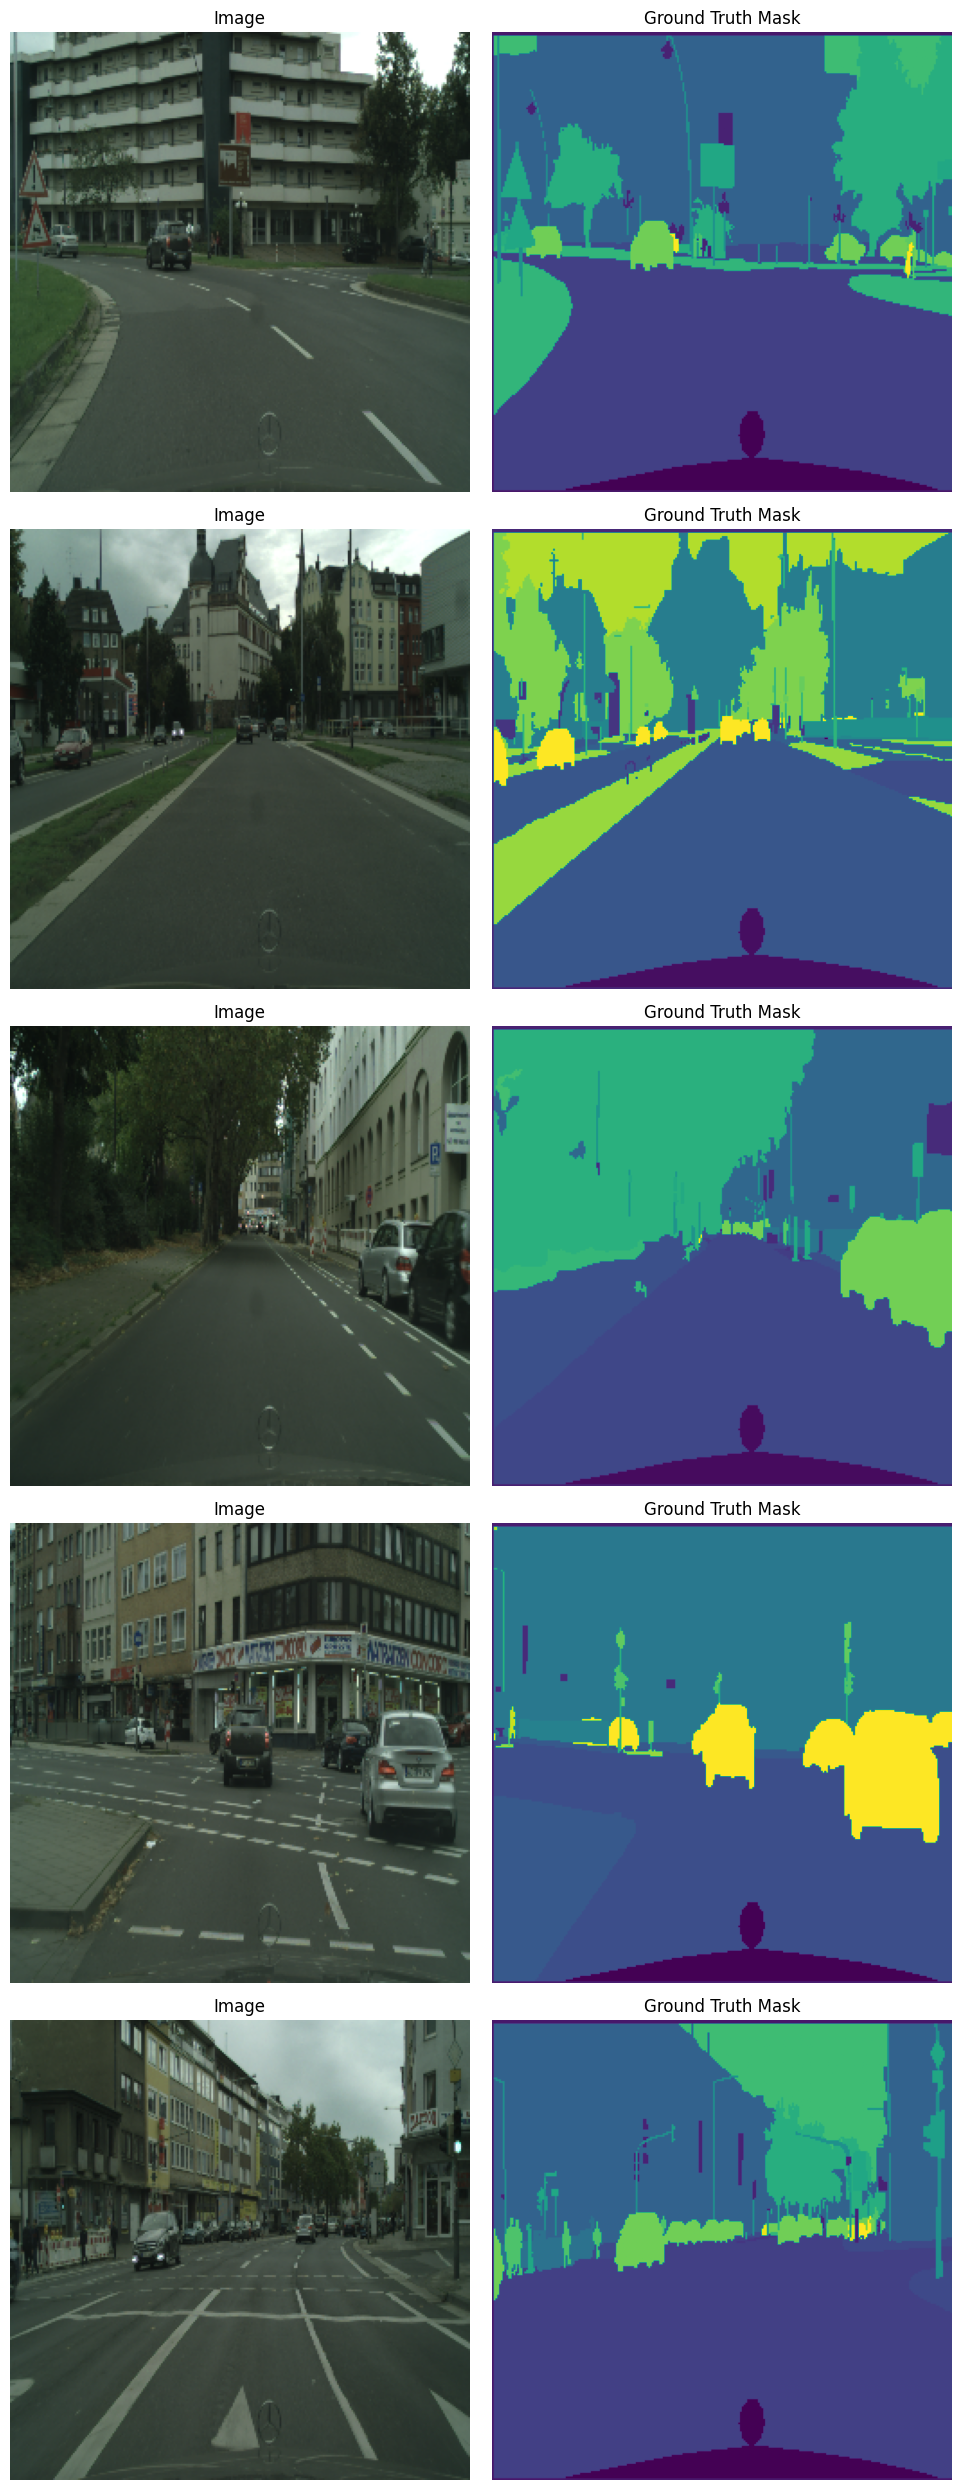

In [6]:
train_dataset = CityscapesDataset(
    transforms=A.Compose([Resize(256, 256)])
)

def visualize_examples(dataset, num_examples=5):
    plt.figure(figsize=(10, 5 * num_examples))

    for idx in range(num_examples):
        # Get the image and mask
        image, mask = dataset[idx]
        # Plot image and mask
        plt.subplot(num_examples, 2, 2 * idx + 1)
        plt.imshow(image)
        plt.title("Image")
        plt.axis("off")

        plt.subplot(num_examples, 2, 2 * idx + 2)
        plt.imshow(mask, cmap="viridis")
        plt.title("Ground Truth Mask")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

visualize_examples(train_dataset, num_examples=5)

In [7]:
class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=34):
        super(UNet, self).__init__()

        # Contracting Path (Encoder)
        self.enc1 = self.conv_block(in_channels, 32)
        self.enc2 = self.conv_block(32, 64)
        self.enc3 = self.conv_block(64, 128)
        self.enc4 = self.conv_block(128, 256)

        # Bottleneck
        self.bottleneck = self.conv_block(256, 512)

        # Expanding Path (Decoder)
        self.upconv4 = self.upconv(512, 256)
        self.dec4 = self.conv_block(512, 256)

        self.upconv3 = self.upconv(256, 128)
        self.dec3 = self.conv_block(256, 128)

        self.upconv2 = self.upconv(128, 64)
        self.dec2 = self.conv_block(128, 64)

        self.upconv1 = self.upconv(64, 32)
        self.dec1 = self.conv_block(64, 32)

        # Final Output Layer
        self.final = nn.Conv2d(32, out_channels, kernel_size=1)

    def conv_block(self, in_channels, out_channels):
        """Two convolutional layers with ReLU activation"""
        return nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
        )

    def upconv(self, in_channels, out_channels):
        """Transposed Convolution for upsampling"""
        return nn.ConvTranspose2d(in_channels, out_channels, kernel_size=2, stride=2)

    def forward(self, x):
        # Encoder Path
        enc1 = self.enc1(x)
        enc2 = self.enc2(nn.MaxPool2d(kernel_size=2, stride=2)(enc1))
        enc3 = self.enc3(nn.MaxPool2d(kernel_size=2, stride=2)(enc2))
        enc4 = self.enc4(nn.MaxPool2d(kernel_size=2, stride=2)(enc3))

        # Bottleneck
        bottleneck = self.bottleneck(nn.MaxPool2d(kernel_size=2, stride=2)(enc4))

        # Decoder Path
        up4 = self.upconv4(bottleneck)
        dec4 = self.dec4(torch.cat((up4, enc4), dim=1))

        up3 = self.upconv3(dec4)
        dec3 = self.dec3(torch.cat((up3, enc3), dim=1))

        up2 = self.upconv2(dec3)
        dec2 = self.dec2(torch.cat((up2, enc2), dim=1))

        up1 = self.upconv1(dec2)
        dec1 = self.dec1(torch.cat((up1, enc1), dim=1))

        # Final Output
        return self.final(dec1)

In [8]:
def calculate_iou(preds, masks, num_classes):
    iou = 0.0
    for class_idx in range(num_classes):
        intersection = ((preds == class_idx) & (masks == class_idx)).sum().item()
        union = ((preds == class_idx) | (masks == class_idx)).sum().item()
        if union > 0:  # Avoid division by zero
            iou += intersection / union
    return iou / num_classes

In [9]:
def train(
        model, dataloader, criterion, optimizer, num_classes
):
    model.train()
    running_loss = 0.0
    total_iou = 0.0
    num_batches = 0

    for images, masks in tqdm(dataloader):
        images = images.to(device)
        masks = masks.to(device)

        # Forward pass
        outputs = model(images)
        if isinstance(outputs, OrderedDict):
            outputs = outputs['out']
        loss = criterion(outputs, masks.long())

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        # Compute IoU for training batch
        preds = torch.argmax(outputs, dim=1)
        batch_iou = calculate_iou(preds, masks, num_classes)
        total_iou += batch_iou

        num_batches += 1

    avg_train_loss = running_loss / len(dataloader)
    avg_train_iou = total_iou / num_batches
    return avg_train_loss, avg_train_iou


def prepare_wandb_mask_overlay(images, masks, preds, class_labels):
    overlays = []
    for i in range(min(len(images), 3)):  # Limit to first 3 images
        overlays.append(
            wandb.Image(
                images[i].cpu().permute(1, 2, 0).numpy(),  # Convert to HWC
                masks={
                    "ground_truth": {"mask_data": masks[i].cpu().numpy(), "class_labels": class_labels},
                    "prediction": {"mask_data": preds[i].cpu().numpy(), "class_labels": class_labels},
                },
            )
        )
    return overlays

def validate(
    model, dataloader, criterion, num_classes, class_labels
):
    model.eval()
    val_loss = 0.0
    total_iou = 0.0
    num_batches = 0
    wandb_overlays = []

    with torch.no_grad():
        for batch_idx, (images, masks) in enumerate(tqdm(dataloader)):
            images = images.to(device)
            masks = masks.to(device)

            # Forward pass
            outputs = model(images)
            if isinstance(outputs, OrderedDict):
                outputs = outputs['out']
            loss = criterion(outputs, masks.long())
            val_loss += loss.item()

            # Compute IoU
            preds = torch.argmax(outputs, dim=1)
            batch_iou = calculate_iou(preds, masks, num_classes)
            total_iou += batch_iou

            # Prepare mask overlays for the first batch
            if batch_idx == 0:
                wandb_overlays = prepare_wandb_mask_overlay(
                    images, masks, preds, class_labels
                )

            num_batches += 1

    avg_val_loss = val_loss / num_batches
    avg_iou = total_iou / num_batches

    # Log mask overlays to WandB
    wandb.log({"validation_overlays": wandb_overlays})

    return avg_val_loss, avg_iou

def fit(
    model, train_loader, val_loader, optimizer, criterion, num_classes, num_epochs=10
):
    for epoch in range(num_epochs):
        val_iou_best = 0

        train_loss, train_iou = train(model, train_loader, criterion, optimizer, num_classes)

        val_loss, val_iou = validate(model, val_loader, criterion, num_classes, id2label)

        if val_iou > val_iou_best:
            val_iou_best = val_iou
            model_name = f"best_model_{val_iou:.3f}.pth"
            torch.save(model.state_dict(), model_name)
            #wandb.save(model_name)

        print(f"Epoch {epoch+1}/{num_epochs}")
        print(f"Train Loss: {train_loss:.4f}, Train IoU: {train_iou:.4f}")
        print(f"Validation Loss: {val_loss:.4f}, Validation IoU: {val_iou:.4f}")

        # Log metrics to WandB
        wandb.log({
            "epoch": epoch + 1,
            "train_loss": train_loss,
            "train_iou": train_iou,
            "val_loss": val_loss,
            "val_iou": val_iou,
        })
    return model

In [10]:
def run(
    exp_name,
    model,
    optimizer,
    criterion,
    train_transforms,
    val_transforms,
    config_init,
    num_epochs,
    batch_size=32,
    num_workers=8
):
    train_dataset = CityscapesDataset(
        transforms=train_transforms,
        mode='train'
    )
    # len_ = len(train_dataset)
    # indices = torch.randperm(len_)[:len_ // 3]
    # train_dataset = Subset(train_dataset, indices)

    val_dataset = CityscapesDataset(
        transforms=val_transforms,
        mode='val'
    )



    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers, drop_last=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers, drop_last=False)

    config_init.update({
        "batch_size": batch_size,
        "num_workers": num_workers,
        "num_epochs": num_epochs,
    })

    run = wandb.init(project="semantic-segmentation", name=exp_name, config=config_init)
    model = fit(model, train_loader, val_loader, optimizer, criterion, num_classes=len(id2label), num_epochs=num_epochs)
    run.finish()

    return model

# Baseline

In [ ]:
LR = 1e-3
WEIGHT_DECAY = 0
INPUT_SHAPE = 256
NUM_EPOCHS = 20

transforms = A.Compose([
    Resize(INPUT_SHAPE, INPUT_SHAPE),
    Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

model = UNet().to(device)
optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
criterion = nn.CrossEntropyLoss()

config_init = {
    "learning_rate": LR,
    "weight_decay|": WEIGHT_DECAY,
    "input_size": INPUT_SHAPE,
    "optimizer": "Adam",
    "scheduler": "None",
    "augmentation": "None",
    "model": "UNet",
    "dataset": "Cityscapes",
    "loss": "CrossEntropy",
}
model = run("unet-baseline", model, optimizer, criterion, transforms, transforms, config_init, num_epochs=NUM_EPOCHS, num_workers=32)

wandb: Using wandb-core as the SDK backend. Please refer to https://wandb.me/wandb-core for more information.
wandb: Currently logged in as: falcon_light. Use `wandb login --relogin` to force relogin


  0%|          | 0/92 [00:00<?, ?it/s]

  0%|          | 0/16 [00:00<?, ?it/s]

Epoch 1/20
Train Loss: 2.1688, Train IoU: 0.0306
Validation Loss: 1.7295, Validation IoU: 0.0494


  0%|          | 0/92 [00:00<?, ?it/s]

...

Epoch 19/20
Train Loss: 0.4840, Train IoU: 0.2722
Validation Loss: 0.5886, Validation IoU: 0.2332


  0%|          | 0/92 [00:00<?, ?it/s]

  0%|          | 0/16 [00:00<?, ?it/s]

Epoch 20/20
Train Loss: 0.4787, Train IoU: 0.2768
Validation Loss: 0.5813, Validation IoU: 0.2361


epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
train_iou,▁▂▄▅▅▆▆▆▆▇▇▇▇▇▇▇▇███
train_loss,█▅▄▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁
val_iou,▁▃▅▅▆▆▆▆▇▇▇▇▇▇▇▇████
val_loss,█▅▄▃▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁
epoch,20
train_iou,0.27675
train_loss,0.47865
val_iou,0.23609
val_loss,0.58133


# Run with dice loss

In [15]:
import torch.nn.functional as F

def multiclass_dice_loss(pred, target, smooth=1e-5):
    """
    Computes Dice Loss for multi-class segmentation.
    Args:
        pred: Tensor of predictions (batch_size, C, H, W).
        target: One-hot encoded ground truth (batch_size, C, H, W).
        smooth: Smoothing factor.
    Returns:
        Scalar Dice Loss.
    """
    pred = F.softmax(pred, dim=1)  # Convert logits to probabilities
    num_classes = pred.shape[1]  # Number of classes (C)
    target_onehot = F.one_hot(target, num_classes).permute(0, 3, 1, 2).float()
    dice = 0  # Initialize Dice loss accumulator
    
    for c in range(num_classes):  # Loop through each class
        if c not in exclude_labels:
            pred_c = pred[:, c]  # Predictions for class c
            target_c = target_onehot[:, c]  # Ground truth for class c
            
            intersection = (pred_c * target_c).sum(dim=(1, 2))  # Element-wise multiplication
            union = pred_c.sum(dim=(1, 2)) + target_c.sum(dim=(1, 2))  # Sum of all pixels
            
            dice += (2. * intersection + smooth) / (union + smooth)  # Per-class Dice score

    return 1 - dice.mean() / (num_classes - len(exclude_labels))  # Average Dice Loss across classes


In [16]:
model = UNet().to(device)
optimizer = optim.Adam(model.parameters(), lr=LR , weight_decay=WEIGHT_DECAY)
criterion = lambda x, y: nn.CrossEntropyLoss()(x, y) + multiclass_dice_loss(x, y)

config_init = {
    "learning_rate": LR,
    "weight_decay": WEIGHT_DECAY,
    "input_size": INPUT_SHAPE,
    "optimizer": "Adam",
    "scheduler": "None",
    "augmentation": "None",
    "model": "UNet",
    "dataset": "Cityscapes",
    "loss": "CrossEntropy+Dice",
}
model = run("unet-baseline+dice", model, optimizer, criterion, transforms,transforms,  config_init, num_epochs=NUM_EPOCHS, num_workers=32)

  0%|          | 0/92 [00:00<?, ?it/s]

  0%|          | 0/16 [00:00<?, ?it/s]

Epoch 1/20
Train Loss: 3.3893, Train IoU: 0.0234
Validation Loss: 2.9343, Validation IoU: 0.0304


  0%|          | 0/92 [00:00<?, ?it/s]

  0%|          | 0/16 [00:00<?, ?it/s]

...

Epoch 19/20
Train Loss: 1.3671, Train IoU: 0.2627
Validation Loss: 1.4594, Validation IoU: 0.2326


  0%|          | 0/92 [00:00<?, ?it/s]

  0%|          | 0/16 [00:00<?, ?it/s]

Epoch 20/20
Train Loss: 1.3511, Train IoU: 0.2686
Validation Loss: 1.4083, Validation IoU: 0.2397


epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
train_iou,▁▃▄▅▅▆▆▆▆▇▇▇▇▇▇▇████
train_loss,█▅▄▃▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁
val_iou,▁▃▄▅▅▆▆▆▇▆▇▇▇▇██▇███
val_loss,█▅▄▃▃▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁
epoch,20
train_iou,0.26863
train_loss,1.35105
val_iou,0.2397
val_loss,1.4083


# Run with augmentations

In [38]:
LR = 1e-3
WEIGHT_DECAY = 0
INPUT_SHAPE = 256
NUM_EPOCHS = 20


train_transforms = A.Compose([
    Resize(INPUT_SHAPE, INPUT_SHAPE),
    A.HorizontalFlip(),
    A.RandomBrightnessContrast(brightness_limit=0.05, contrast_limit=0.05, p=0.5),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

val_transforms = A.Compose([
    Resize(INPUT_SHAPE, INPUT_SHAPE),
    Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

model = UNet().to(device)
optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
criterion = lambda x, y: nn.CrossEntropyLoss()(x, y)

config_init = {
    "learning_rate": LR,
    "weight_decay": WEIGHT_DECAY,
    "input_size": INPUT_SHAPE,
    "optimizer": "Adam",
    "scheduler": "None",
    "augmentation": '''
        Resize(324, 324),
        HorizontalFlip(),
        RandomCrop(width=256, height=256),
        RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
        GaussianBlur(blur_limit=(3, 5), p=0.3)
    ''',
    "model": "UNet",
    "dataset": "Cityscapes",
    "loss": "CrossEntropy",
}
model = run("unet-baseline+aug", model, optimizer, criterion, train_transforms, val_transforms, config_init, num_epochs=NUM_EPOCHS, num_workers=16)

  0%|          | 0/92 [00:00<?, ?it/s]

  0%|          | 0/16 [00:00<?, ?it/s]

Epoch 1/20
Train Loss: 2.5083, Train IoU: 0.0207
Validation Loss: 1.8153, Validation IoU: 0.0455


  0%|          | 0/92 [00:00<?, ?it/s]

  0%|          | 0/16 [00:00<?, ?it/s]

...

Epoch 19/20
Train Loss: 0.5849, Train IoU: 0.2311
Validation Loss: 0.6287, Validation IoU: 0.2069


  0%|          | 0/92 [00:00<?, ?it/s]

  0%|          | 0/16 [00:00<?, ?it/s]

Epoch 20/20
Train Loss: 0.5754, Train IoU: 0.2331
Validation Loss: 0.6167, Validation IoU: 0.2112


epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
train_iou,▁▂▃▅▅▆▆▆▇▇▇▇▇███████
train_loss,█▄▃▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁
val_iou,▁▂▄▄▅▆▆▆▆▇▇▇▇▇▇▇████
val_loss,█▅▄▃▃▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁
epoch,20
train_iou,0.23308
train_loss,0.57544
val_iou,0.21121
val_loss,0.61673


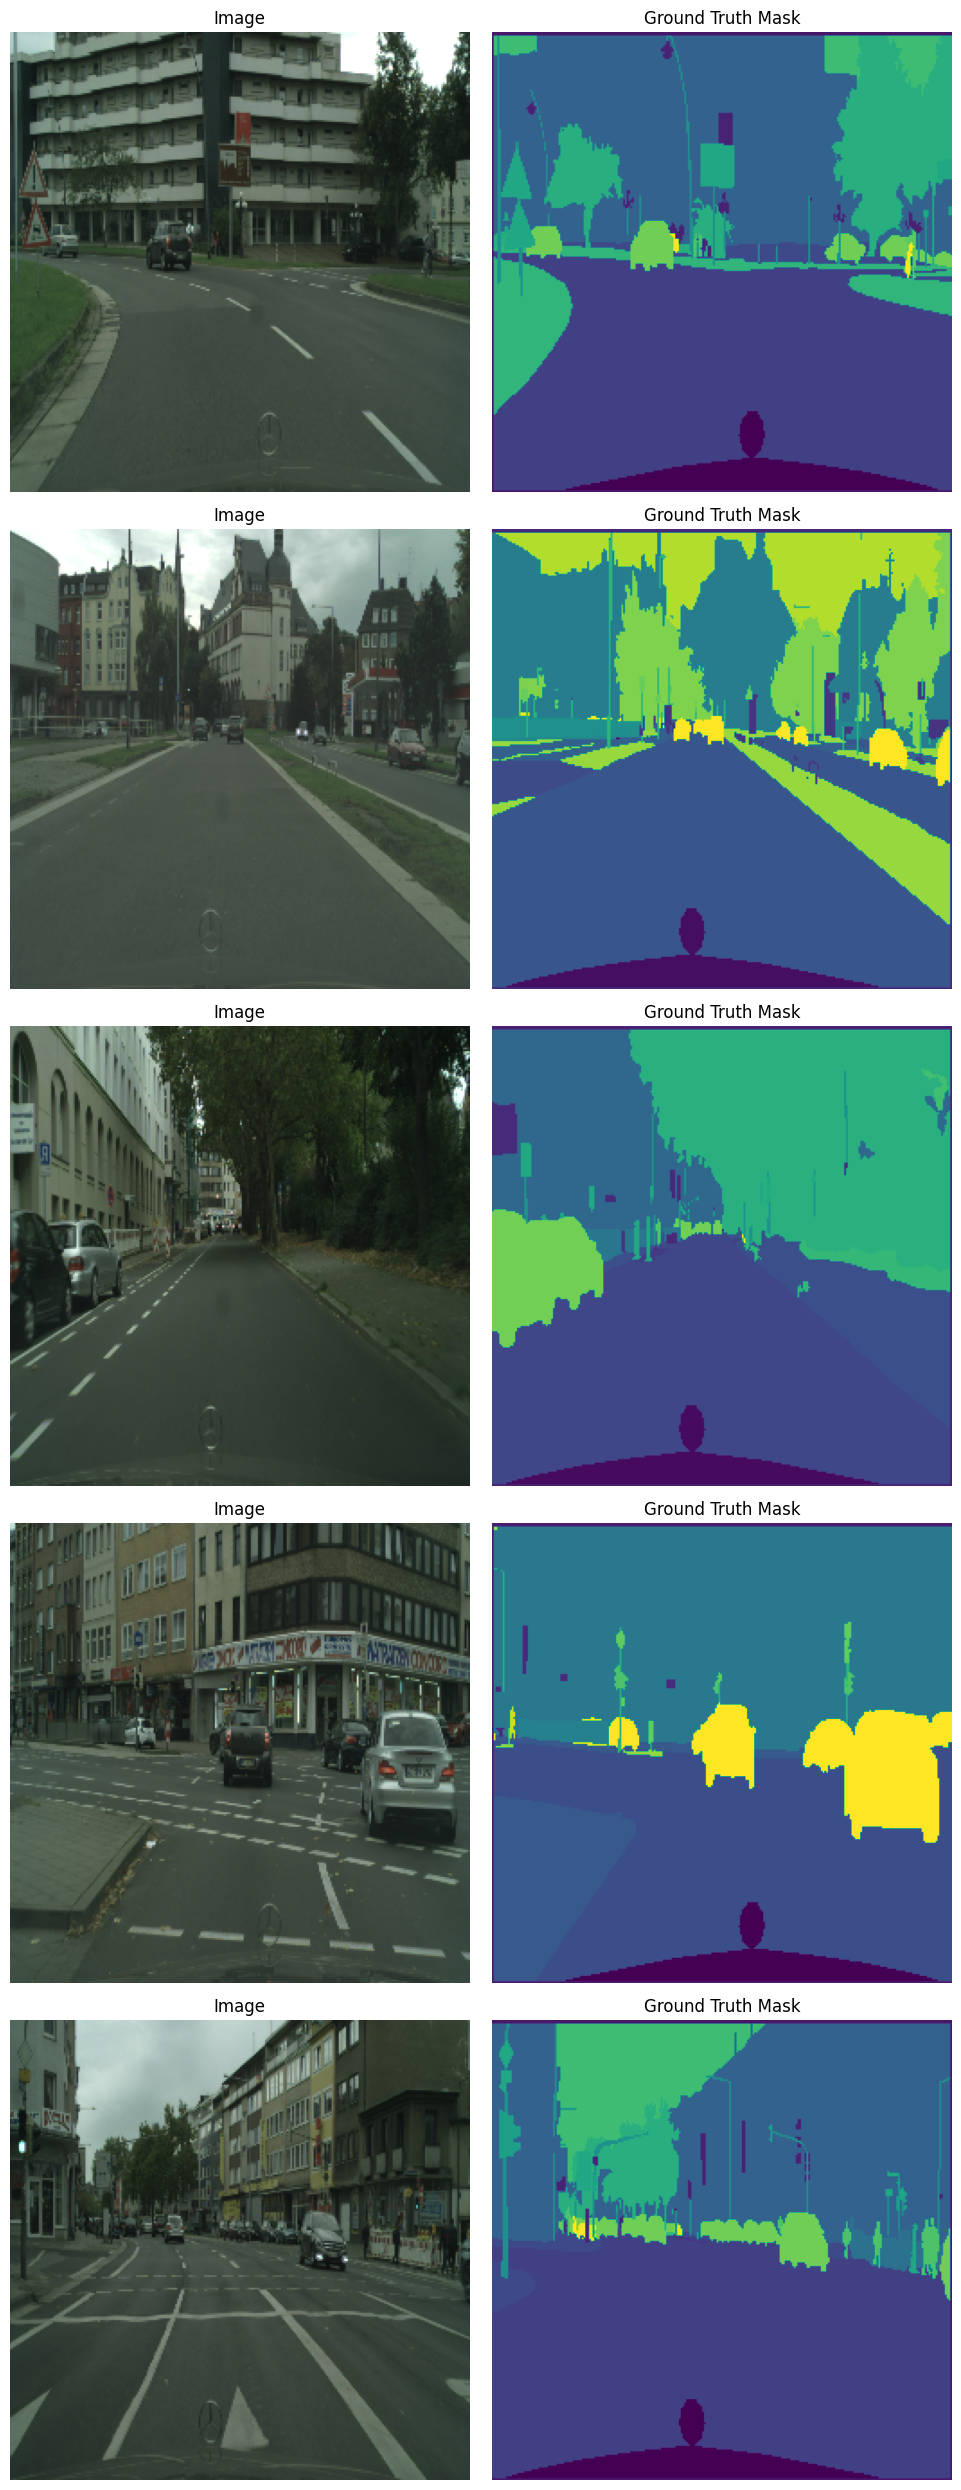

In [37]:
train_transforms = A.Compose([
    Resize(INPUT_SHAPE, INPUT_SHAPE),
    A.HorizontalFlip(),
    A.RandomBrightnessContrast(brightness_limit=0.1, contrast_limit=0.1, p=0.3),
])

train_dataset = CityscapesDataset(
    transforms=train_transforms
)

visualize_examples(train_dataset, num_examples=5)

# Run with pretrained model

In [11]:
def run_finetune(
    exp_name,
    model,
    criterion,
    train_transforms,
    val_transforms,
    config_init,
    num_epochs,
    batch_size=32,
    num_workers=32
):
    train_dataset = CityscapesDataset(
        transforms=train_transforms,
        mode='train'
    )

    val_dataset = CityscapesDataset(
        transforms=val_transforms,
        mode='val'
    )



    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers, drop_last=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers, drop_last=False)

    config_init.update({
        "batch_size": batch_size,
        "num_workers": num_workers,
        "num_epochs": num_epochs,
    })

    run = wandb.init(project="semantic-segmentation", name=exp_name, config=config_init)

    # Freeze the backbone for the first epoch
    for param in model.backbone.parameters():
        param.requires_grad = False

    # Train for 2 epoch with frozen backbone and lr=0.001
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.001)
    fit(model, train_loader, val_loader, optimizer, criterion, num_classes=len(id2label), num_epochs=2)

    # Unfreeze the backbone and train for the remaining epochs with lr=0.0001
    for param in model.backbone.parameters():
        param.requires_grad = True

    optimizer = optim.Adam(model.parameters(), lr=0.0001)
    fit(model, train_loader, val_loader, optimizer, criterion, num_classes=len(id2label), num_epochs=num_epochs-2)

    run.finish()

    return model

In [57]:
import gc
gc.collect()
torch.cuda.empty_cache()

In [13]:
from torchvision.models.segmentation import deeplabv3_resnet50, DeepLabV3_ResNet50_Weights

WEIGHT_DECAY = 0
INPUT_SHAPE = 256
NUM_EPOCHS = 20

model = deeplabv3_resnet50(weights=DeepLabV3_ResNet50_Weights.DEFAULT)
model.classifier[4] = torch.nn.Conv2d(256, NUM_CLASSES, kernel_size=(1, 1))
model = model.to(device)

criterion = lambda x, y: nn.CrossEntropyLoss()(x, y)

val_transforms = A.Compose([
    Resize(INPUT_SHAPE, INPUT_SHAPE),
    Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

config_init = {
    "learning_rate": LR,
    "weight_decay": WEIGHT_DECAY,
    "input_size": INPUT_SHAPE,
    "optimizer": "Adam",
    "scheduler": "None",
    "augmentation": '''
        Resize(324, 324),
        HorizontalFlip(),
        RandomCrop(width=256, height=256),
        RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
        GaussianBlur(blur_limit=(3, 5), p=0.3)
    ''',
    "model": "UNet",
    "dataset": "Cityscapes",
    "loss": "CrossEntropy",}

model = run_finetune("deeplab", model, criterion, val_transforms, val_transforms, config_init, num_epochs=NUM_EPOCHS, num_workers=32, batch_size=16)

wandb: Using wandb-core as the SDK backend. Please refer to https://wandb.me/wandb-core for more information.
wandb: Currently logged in as: falcon_light. Use `wandb login --relogin` to force relogin


  0%|          | 0/185 [00:00<?, ?it/s]

  0%|          | 0/32 [00:00<?, ?it/s]

Epoch 1/2
Train Loss: 0.9435, Train IoU: 0.1480
Validation Loss: 0.7520, Validation IoU: 0.1642


  0%|          | 0/185 [00:00<?, ?it/s]

...

Epoch 17/18
Train Loss: 0.2100, Train IoU: 0.4922
Validation Loss: 0.5289, Validation IoU: 0.2832


  0%|          | 0/185 [00:00<?, ?it/s]

  0%|          | 0/32 [00:00<?, ?it/s]

Epoch 18/18
Train Loss: 0.2088, Train IoU: 0.4930
Validation Loss: 0.5263, Validation IoU: 0.2815


epoch,▁▁▁▁▂▂▃▃▃▄▄▅▅▆▆▆▇▇██
train_iou,▁▂▃▄▄▅▅▆▆▆▇▇▇▇██████
train_loss,█▆▄▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁
val_iou,▁▂▅▅▆▆▇▇▇█▇█████████
val_loss,█▇▃▁▁▁▁▁▂▁▂▂▁▁▂▂▂▂▂▂
epoch,18
train_iou,0.49301
train_loss,0.20881
val_iou,0.28152
val_loss,0.52627
